In [1]:
%run header.ipynb

def css_styling():
    styles = open("custom.css", "r").read()
    return HTML(styles)
css_styling()


# STFT 

Signals can be represented in the so called *time-frequency-domain*.
This can be useful for calculations and signal manipulations, as well as for 
visualization, since this shows the evolution of a signal's spectrum over time.
This visual representation is referred to as *spectrogram*.
The *short-time Fourier transform* (STFT) devides a signal into overlapping
segments - or frames - of equal length and calculates a Fourier transform for each frame.

$$
\mathrm{STFT}(i,j) = \sum_{n=-N/2}^{N/2} x[n] w[n] e^{-j 2 \pi f n}
$$

## Window Function

Window functions are used to avoid spectral leakage. In case of the STFT, this can be a hann 

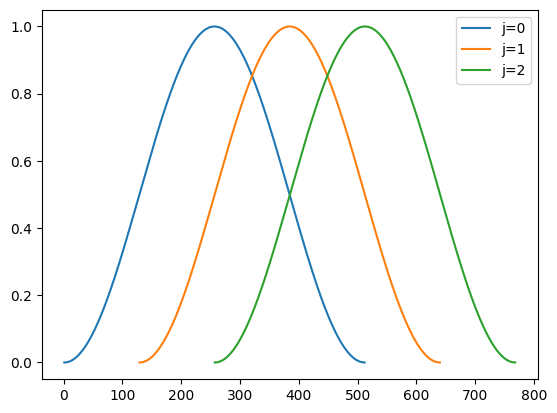

In [2]:
w = signal.windows.hann(512)

x = np.linspace(1,512,512)
X = fft(x)

plt.plot(x,w)
plt.plot(x+128,w)
plt.plot(x+2*128,w)

plt.legend(['j=0','j=1','j=2']);


Typical framesizes $L_f$ range from $10$ to $40\ \mathrm{ms}$.
Overlaps vary from $0$ percent to $90$ percent.

The larger the frames, the better the frequency resolution.
The larger the overlap, the better the time resolution.

## Violin

For musical sounds with a pitch, the spectrogram shows the individual partials
as prominent horizontal lines. The following spectrogram of a violin sound,
recorded with a sampling rate of $f_s = 96\ \mathrm{kHz}$ is calculated with a framesize of $4096$ samples and an overlap of $2048$ samples:


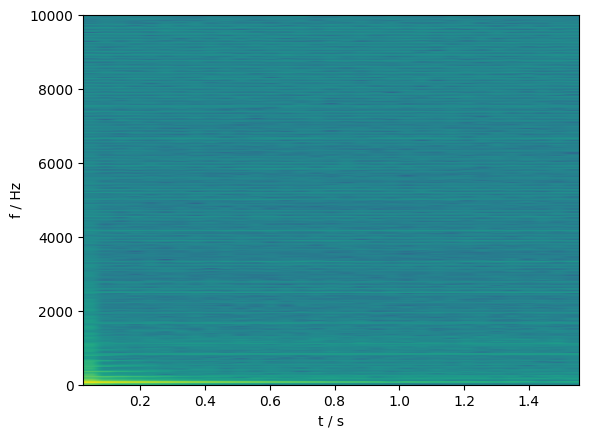

In [3]:
url = 'https://ringbuffer.org/download/audio/MFB-522/kick_1.wav'
x, fs = sf.read(io.BytesIO(urlopen(url).read()))

# f, t, Sxx = signal.spectrogram(x, fs)
 
powerSpectrum, freqenciesFound, time, imageAxis = plt.specgram(x, NFFT=4096, noverlap = 2048, Fs=fs);

plt.ylim((0,10000))

plt.ylabel('f / Hz');
plt.xlabel('t / s');
plt.show;


<div class="alert alert-block alert-info">
    <b>Exercise:</b> Calculate the framesize and overlap in seconds. What is the maximum represented frequency?
</div>
